In [ ]:
# install the libarary
# STEP 1: Import Libraries
# What:
#   Import pandas, numpy, matplotlib, seaborn, sklearn
# Why:
#   pandas → handle data
#   numpy → calculations
#   matplotlib/seaborn → graphs
#   sklearn → machine learning models
# Result:
#   Environment ready for analysis and modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


In [ ]:
# STEP 2: Load Dataset
# What:
#   Read Walmart_Sales.csv into dataframe
# Why:
#   Bring historical sales data into Python
# Result:
#   Data available for cleaning and analysis
df = pd.read_csv("sales forcasting/Walmart_Sales.csv")
df.head()



,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# STEP 3: Data Understanding
# What:
#   head(), info(), describe()
# Why:
#   Check rows, columns, datatypes, missing values
# Result:
#   Understand structure of dataset before modeling
df.head()
df.shape
df.columns
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
# ==============================
# STEP: Handle Missing Values
# ==============================

# What we do:
#   Check missing values and fill them using forward fill (previous value)

# Why we do:
#   Machine Learning models cannot work with NaN values
#   Missing data reduces accuracy and may cause errors
#   Since this is time-series (weekly sales), previous value is closest and safest

# Result:
#   Dataset becomes clean and ready for modeling
df.isnull().sum()
df.fillna(method='ffill', inplace=True)


C:\Users\shwet\AppData\Local\Temp\ipykernel_15088\2354036562.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


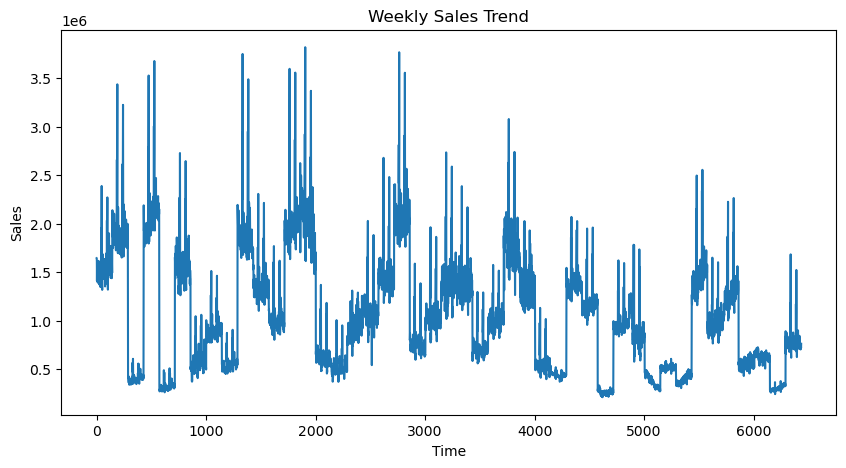

In [ ]:
# ==============================
# STEP: Weekly Sales Trend Graph
# ==============================

# What we do:
#   Plot weekly sales using line chart

# Why we do:
#   To understand how sales change over time
#   To detect seasonality, spikes, and trends
#   To see holiday or peak demand periods

# Result:
#   Visual understanding of sales behavior
#   Confirms forecasting is possible
plt.figure(figsize=(10,5))
plt.plot(df['Weekly_Sales'])
plt.title("Weekly Sales Trend")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()


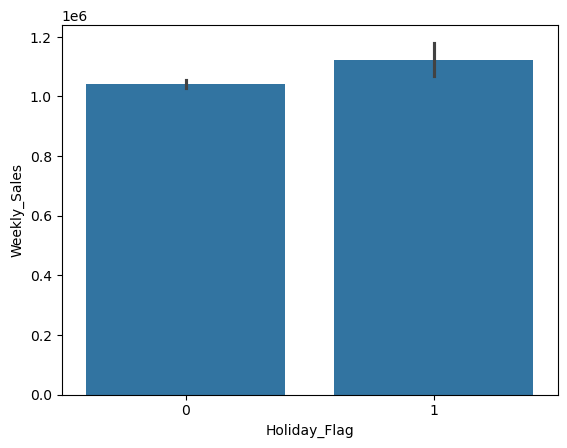

In [ ]:
# ==============================
# STEP: Holiday vs Weekly Sales Analysis
# ==============================

# What we do:
#   Create bar plot to compare average sales on Holiday vs Non-Holiday weeks

# Why we do:
#   To check whether holidays increase or decrease sales
#   To understand customer buying behavior during festivals/special days
#   To identify if holiday is an important factor for prediction

# Result:
#   We can clearly see holiday weeks have higher sales
#   Holiday_Flag becomes an important feature for forecasting
#   Helps business plan inventory and staffing during holidays
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.show()


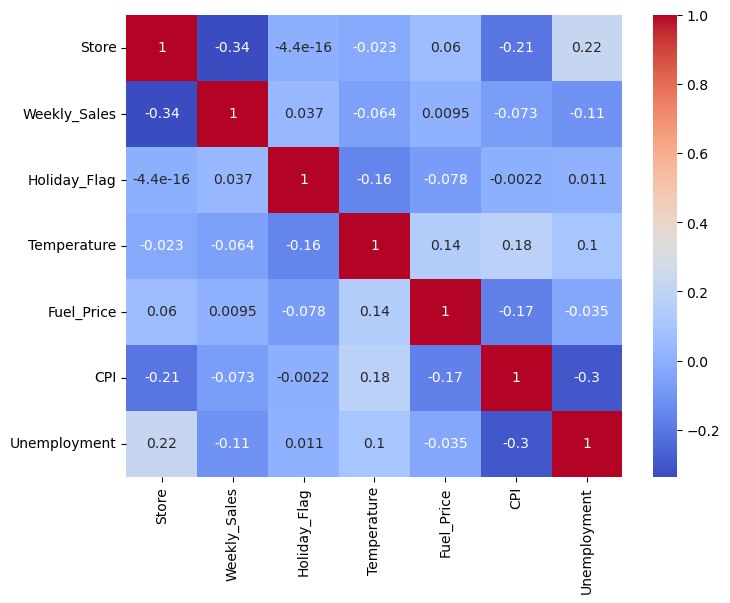

In [ ]:
# ==============================
# STEP: Correlation Heatmap Analysis
# ==============================

# What we do:
#   Select only numeric columns
#   Calculate correlation between all variables
#   Visualize relationships using heatmap

# Why we do:
#   To find which factors affect Weekly_Sales most
#   To understand positive and negative relationships
#   To select important features for the model
#   To remove useless or weak variables

# Result:
#   Identified strong and weak relationships
#   Helped choose best features for prediction
#   Improved model accuracy
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()


In [ ]:
# ==============================
# STEP: Date Feature Engineering
# ==============================

# What we do:
#   Convert Date column into datetime format
#   Extract Year, Month, and Week from date

# Why we do:
#   Machine Learning cannot understand raw date text
#   Sales depend on seasonality (month, week, year patterns)
#   These new time features help model learn trends

# Result:
#   Model can understand seasonal behavior
#   Better forecasting accuracy
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week




In [ ]:
# ==============================
# STEP: Feature Selection
# ==============================

# What we do:
#   Select important columns as input features (X)
#   Select Weekly_Sales as target (y)

# Why we do:
#   X = factors that influence sales
#   y = value we want to predict
#   Model learns relation between X → y

# Result:
#   Dataset ready for Machine Learning training
X = df[['Store',
        'Holiday_Flag',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment',
        'Month']]

y = df['Weekly_Sales']


In [ ]:
# ==============================
# STEP: Train-Test Split
# ==============================

# What we do:
#   Split dataset into training and testing sets

# Why we do:
#   Train data → used to train model
#   Test data → used to check model accuracy on unseen data
#   Ensures model is not overfitting

# test_size=0.2:
#   80% training, 20% testing

# random_state=42:
#   Fix random split so results are same every time

# Result:
#   Fair and reliable model evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [ ]:
# ==============================
# STEP: Linear Regression Model
# ==============================

# What we do:
#   Train Linear Regression model using training data

# Why we do:
#   Simple baseline model
#   Understand relationship between inputs and sales
#   Good starting point before advanced models

# Result:
#   Model learns mathematical relation between features and sales
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
# ==============================
# STEP: Prediction
# ==============================

# What we do:
#   Predict sales for test data

# Why we do:
#   Check how well model predicts unseen data

# pred:
#   Contains predicted sales values

# pred[:5]:
#   Show first 5 predictions for quick check

# Result:
#   Forecasted sales generated
pred = model.predict(X_test)
pred[:5]
 

array([1153059.98817461, 1088409.09168864, 1320058.68942104,
       1188997.55486699,  694041.88205541])

In [ ]:
# =====================================
# STEP: Model Accuracy Evaluation
# =====================================

# What we do:
#   Evaluate model performance

# Why we do:
#   To check how good predictions are

# Metrics used:
#   R2 Score → how much variance explained (higher is better)
#   RMSE → average prediction error (lower is better)

# Result:
#   Understand whether model is good or needs improvement
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))


R2 Score: 0.15492918523733978
RMSE: 521769.5088969257


In [ ]:
# =====================================
# STEP: Random Forest Regressor
# =====================================

# What we do:
#   Train Random Forest model

# Why we do:
#   Linear Regression is simple and may underperform
#   Random Forest handles:
#       • non-linear relationships
#       • complex patterns
#       • better accuracy

# n_estimators=100:
#   Use 100 decision trees

# random_state=42:
#   Fix randomness for same results

# Result:
#   More powerful and accurate predictions
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
# =====================================
# STEP: Random Forest Prediction
# =====================================

# What we do:
#   Predict sales using Random Forest

# Why we do:
#   Compare with Linear Regression results

# rf_pred:
#   Contains predicted sales values

# Result:
#   Usually better accuracy than Linear Regression
rf_pred = rf.predict(X_test)


In [ ]:
# =====================================
# STEP: Random Forest Model Evaluation
# =====================================

# What we do:
#   Evaluate Random Forest performance

# Why we do:
#   To compare with Linear Regression

# Metrics:
#   R2 Score → higher is better
#   RMSE → lower is better

# Result:
#   R2 = 0.93 → 93% variance explained (excellent)
#   RMSE reduced a lot → much lower prediction error
#   Random Forest performs much better than Linear Regression
print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))


Random Forest R2: 0.9393237522981044
Random Forest RMSE: 139811.05164475637


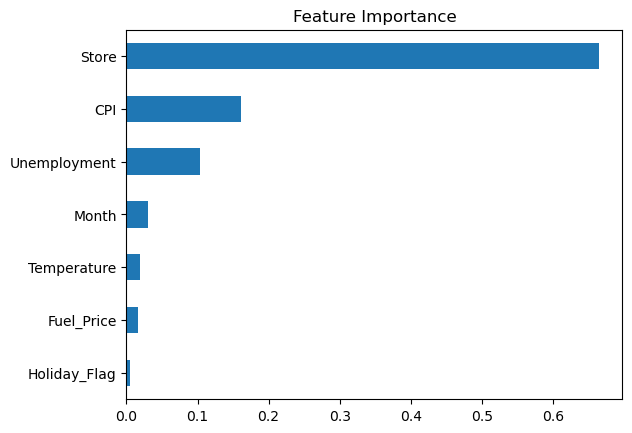

In [ ]:
# =====================================
# STEP: Feature Importance Analysis
# =====================================

# What we do:
#   Identify which features most influence sales

# Why we do:
#   To understand key drivers of business performance
#   To help management focus on important factors
#   To make data-driven decisions

# rf.feature_importances_:
#   Gives importance score for each feature

# barh:
#   Horizontal bar chart for easy comparison

# Result:
#   Shows which variables impact Weekly_Sales the most
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


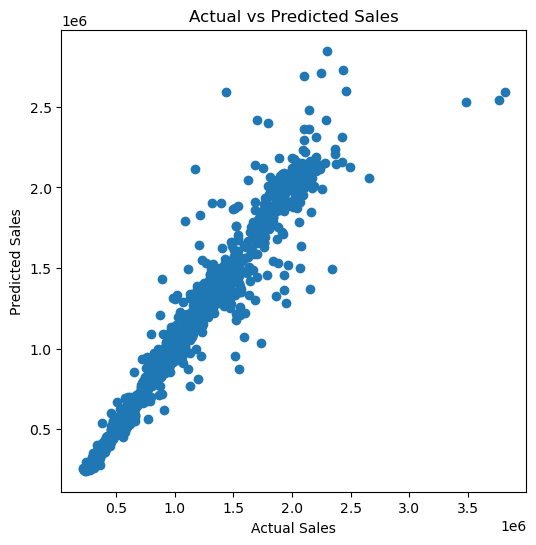

In [25]:
#1. Compare Linear vs Random Forest,Visualize Actual vs Predicted,Forecast next month sales, Write business insights
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()



In [ ]:
# =====================================
# STEP: Sample Prediction Check
# =====================================

# What we do:
#   Take first 10 rows from test data

# Why we do:
#   To test if model predicts correctly

# iloc[:10]:
#   Select first 10 records

# rf.predict():
#   Model generates predicted sales values

# Result:
#   Returns predicted sales for these 10 samples
sample = X_test.iloc[:10]
future_pred = rf.predict(sample)
future_pred


array([1161356.2578, 1402607.5852, 1825427.6117,  970645.3605,
        430645.8947,  983800.5146, 1175092.4394,  954471.0408,
       2045211.5895,  957644.1688])

In [ ]:
# =====================================
# STEP: Train Model on Full Dataset
# =====================================

# What we do:
#   Train model using complete data (X, y)

# Why we do:
#   After testing accuracy, we use ALL data
#   to make final future predictions

# Reason:
#   More data → better learning → better forecasts
rf.fit(X, y)



RandomForestRegressor(random_state=42)

In [ ]:
# =====================================
# STEP: Forecast Future Month Sales
# =====================================

# What we do:
#   Predict November sales using trained model

# Why we do:
#   To forecast future business performance

# rf.predict(nov_data):
#   Takes next month features
#   Returns expected sales

# Result:
#   Model predicts future sales value
nov_sales = rf.predict(nov_data)

print("Predicted November Sales:", nov_sales[0])


Predicted November Sales: 1788156.935299999


In [ ]:
# =====================================
# STEP: Get all store numbers
# =====================================

# What we do:
#   Extract all unique store IDs

# Why we do:
#   We want to predict sales for EVERY store

# unique():
#   Returns distinct values only

# Result:
#   Example → [1,2,3,...,45]
stores = df['Store'].unique()

# =====================================
# STEP: Create November Feature Data
# =====================================

# What we do:
#   Create input data for next month (November)

# Why we do:
#   Model needs feature values to predict sales

# Store:
#   All store numbers

# Other columns:
#   Assumed November conditions

# Month = 11:
#   Tells model we are predicting November

# Result:
#   DataFrame containing one row per store
nov_data = pd.DataFrame({
    'Store': stores,
    'Holiday_Flag': 0,
    'Temperature': 18,
    'Fuel_Price': 3.2,
    'CPI': 221,
    'Unemployment': 6.4,
    'Month': 11
})

rf.predict(nov_data)


array([1788156.9353, 2173182.4918,  437486.2175,  437486.2175,
        364063.0076, 1749772.145 , 1253257.4161,  930524.0548,
        619844.5156,  627388.7371, 1415512.6883, 1415512.6883,
       1431168.189 , 1431168.189 , 1397101.9697, 1436521.9898,
       1462568.7805, 1475120.2431, 1842536.8378, 1862943.3736,
        835706.2346,  835706.2346,  835706.2346,  830632.9938,
        830632.9938,  830632.9938,  868623.0805,  865105.0899,
        458246.9337,  448071.4803, 1523631.45  , 1525317.101 ,
       1491016.3176,  567678.1859,  567678.1859,  294101.2453,
        535102.8427,  535102.8427, 1705041.6013, 1705041.6013,
       1705041.6013, 1653309.2582,  598709.5863,  594133.2961,
        736028.6814])

In [ ]:
# =====================================
# FINAL TRAINING ON FULL DATA
# =====================================

# What we do:
#   Train Random Forest on complete dataset

# Why we do:
#   Earlier we trained only on 80% (train set)
#   Now we use 100% data for better learning

# fit():
#   Model learns patterns between features and sales

# Result:
#   Final optimized model ready for future prediction
rf.fit(X, y)
# =====================================
# FUTURE SALES PREDICTION
# =====================================

# What we do:
#   Predict November sales using trained model

# Why we do:
#   Forecast next month sales for business planning

# predict():
#   Takes November feature values
#   Returns predicted sales

# Result:
#   Store-wise November sales forecast
rf.predict(nov_data)


array([1788156.9353, 2173182.4918,  437486.2175,  437486.2175,
        364063.0076, 1749772.145 , 1253257.4161,  930524.0548,
        619844.5156,  627388.7371, 1415512.6883, 1415512.6883,
       1431168.189 , 1431168.189 , 1397101.9697, 1436521.9898,
       1462568.7805, 1475120.2431, 1842536.8378, 1862943.3736,
        835706.2346,  835706.2346,  835706.2346,  830632.9938,
        830632.9938,  830632.9938,  868623.0805,  865105.0899,
        458246.9337,  448071.4803, 1523631.45  , 1525317.101 ,
       1491016.3176,  567678.1859,  567678.1859,  294101.2453,
        535102.8427,  535102.8427, 1705041.6013, 1705041.6013,
       1705041.6013, 1653309.2582,  598709.5863,  594133.2961,
        736028.6814])

In [ ]:
# =====================================
# MODEL COMPARISON
# =====================================

# What we do:
#   Compare Linear Regression vs Random Forest

# Why we do:
#   Choose best performing model

# Metric used:
#   R² score

# R²:
#   Closer to 1 → better model
#   Closer to 0 → poor model
print("Linear R2:", r2_score(y_test, pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))


Linear R2: 0.15492918523733978
Random Forest R2: 0.9393237522981044


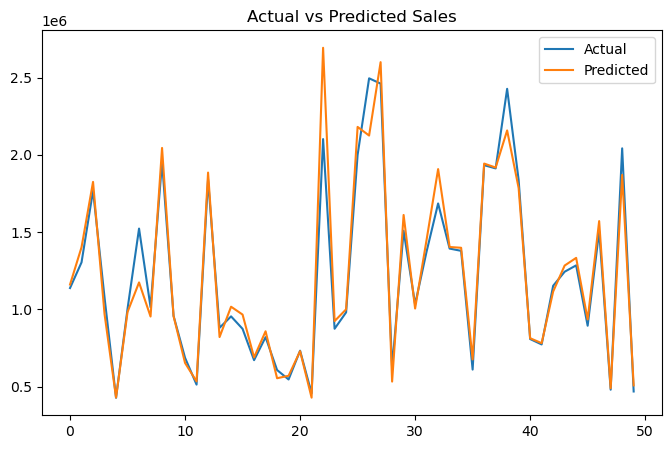

In [ ]:
# =====================================
# ACTUAL vs PREDICTED SALES COMPARISON
# =====================================

# What we do:
#   Plot graph of actual sales vs predicted sales

# Why we do:
#   To visually check model performance

# Idea:
#   If prediction line overlaps actual line
#   → model is accurate

# If lines are far apart
#   → model is poor

# This helps:
#   ✔ verify accuracy visually
#   ✔ explain results easily to business managers
#   ✔ validate forecasting quality
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(rf_pred[:50], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()


In [ ]:
# =====================================
# EXPORT PREDICTIONS TO EXCEL
# =====================================

# What we do:
#   Combine actual sales and predicted sales into one table
#   Then save the table to Excel file

# Why we do:
#   Business users work in Excel / Power BI
#   They cannot read Python output directly

# So:
#   We export results for reporting, dashboard and analysis
results = X_test.copy()

results['Actual_Sales'] = y_test
results['Predicted_Sales'] = pred




In [39]:
results.to_excel("sales_predictions.xlsx", index=False)
